In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [69]:
# df = pd.read_csv('../reports/python3_report/pairs.csv')
# df.sort_values('similarity', ascending=False, inplace=True)

df = pd.DataFrame()
for lang in ['cpp', 'python3', 'python', 'java', 'javascript', 'golang', 'c', 'rust']:
    lang_df = pd.read_csv(f'../reports/{lang}_report/pairs.csv')
    lang_df['submission_id_left'] = lang_df['leftFilePath'].map(lambda x: int(x.split('.')[0]))
    lang_df['submission_id_right'] = lang_df['rightFilePath'].map(lambda x: int(x.split('.')[0]))
    lang_df['language'] = lang
    df = pd.concat([df, lang_df], ignore_index=True)
meta = pd.read_json('../data/parsed_submissions.json')

# meta
df = df.merge(meta[['submission_id', 'user_slug', 'problem_number', 'rank']], left_on='submission_id_left', right_on='submission_id', how='left')
df = df.merge(meta[['submission_id', 'user_slug', 'problem_number', 'rank']], left_on='submission_id_right', right_on='submission_id', how='left', suffixes=('_left_merge', '_right_merge'))
df

,id,leftFileId,leftFilePath,rightFileId,rightFilePath,similarity,totalOverlap,longestFragment,leftCovered,rightCovered,...,submission_id_right,language,submission_id_left_merge,user_slug_left_merge,problem_number_left_merge,rank_left_merge,submission_id_right_merge,user_slug_right_merge,problem_number_right_merge,rank_right_merge
0,7195,53,2124450936.cpp,96,2124461242.cpp,0.839572,157,55,78,79,...,2124461242,cpp,2124450936,shiwang_1441,4380,36,2124461242,mohit6573,4380,31
1,9739,93,2124460752.cpp,115,2124470694.cpp,0.865169,154,46,77,77,...,2124470694,cpp,2124460752,aryansudhir,4379,66,2124470694,aryansudhir,4380,66
2,10023,110,2124464219.cpp,121,2124470277.cpp,0.641350,152,39,76,76,...,2124470277,cpp,2124464219,Jim_X,4379,64,2124470277,Jim_X,4380,64
3,10200,116,2124467454.cpp,118,2124473493.cpp,0.808642,131,47,67,64,...,2124473493,cpp,2124467454,hewhocodes,4379,82,2124473493,hewhocodes,4380,82
4,8829,65,2124454595.cpp,72,2124457575.cpp,0.456204,125,40,68,57,...,2124457575,cpp,2124454595,Swetha_VEC,4380,95,2124457575,Swetha_VEC,4379,95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14999,383,0,2124456728.rs,5,2124469009.rs,0.000000,0,0,0,0,...,2124469009,rust,2124456728,m-hu,4410,73,2124469009,m-hu,4379,73
15000,384,0,2124456728.rs,7,2124471868.rs,0.000000,0,0,0,0,...,2124471868,rust,2124456728,m-hu,4410,73,2124471868,m-hu,4380,73
15001,385,2,2124465159.rs,6,2124465516.rs,0.000000,0,0,0,0,...,2124465516,rust,2124465159,m-hu,4401,73,2124465516,vremyavnikuda,4380,43
15002,386,2,2124465159.rs,5,2124469009.rs,0.000000,0,0,0,0,...,2124469009,rust,2124465159,m-hu,4401,73,2124469009,m-hu,4379,73


In [70]:
df_non_user = df[df['user_slug_left_merge'] != df['user_slug_right_merge']]
df_diff_questions = df_non_user[df_non_user['problem_number_left_merge'] == df_non_user['problem_number_right_merge']]
df_diff_questions.sort_values('similarity', ascending=False)

,id,leftFileId,leftFilePath,rightFileId,rightFilePath,similarity,totalOverlap,longestFragment,leftCovered,rightCovered,...,submission_id_right,language,submission_id_left_merge,user_slug_left_merge,problem_number_left_merge,rank_left_merge,submission_id_right_merge,user_slug_right_merge,problem_number_right_merge,rank_right_merge
7626,5020,57,2124457660.py,72,2124463641.py,1.0,166,81,83,83,...,2124463641,python3,2124457660,Aveshgour,4380,20,2124463641,anassharafat,4380,35
7627,4536,49,2124453953.py,75,2124463012.py,1.0,156,78,78,78,...,2124463012,python3,2124453953,Aveshgour,4379,20,2124463012,anassharafat,4379,35
7817,4234,39,2124451978.py,46,2124454192.py,1.0,52,26,26,26,...,2124454192,python3,2124451978,bhuiyan__fahim,4401,16,2124454192,113225081017_KamarajK,4401,37
7831,3399,26,2124448947.py,67,2124461754.py,1.0,50,25,25,25,...,2124461754,python3,2124448947,Aveshgour,4410,20,2124461754,anassharafat,4410,35
7862,2122,7,2124445541.py,32,2124450202.py,1.0,46,23,23,23,...,2124450202,python3,2124445541,anshulp2830,4401,38,2124450202,lohi_17,4401,60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4334,2817,3,2124444772.cpp,14,2124445385.cpp,0.0,0,0,0,0,...,2124445385,cpp,2124444772,pv16ZejYRl,4410,29,2124445385,Swetha_VEC,4410,95
4333,2815,3,2124444772.cpp,13,2124445336.cpp,0.0,0,0,0,0,...,2124445336,cpp,2124444772,pv16ZejYRl,4410,29,2124445336,hewhocodes,4410,82
4342,2835,3,2124444772.cpp,32,2124448370.cpp,0.0,0,0,0,0,...,2124448370,cpp,2124444772,pv16ZejYRl,4410,29,2124448370,nafiz457,4410,76
5971,5945,31,2124447575.cpp,39,2124449906.cpp,0.0,0,0,0,0,...,2124449906,cpp,2124447575,bella__ciao,4401,26,2124449906,lev_mark,4401,13


C:\Users\Vignesh\AppData\Local\Temp\ipykernel_24596\2564581202.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_diff_questions, x='similarity', y='language', palette='Set2')


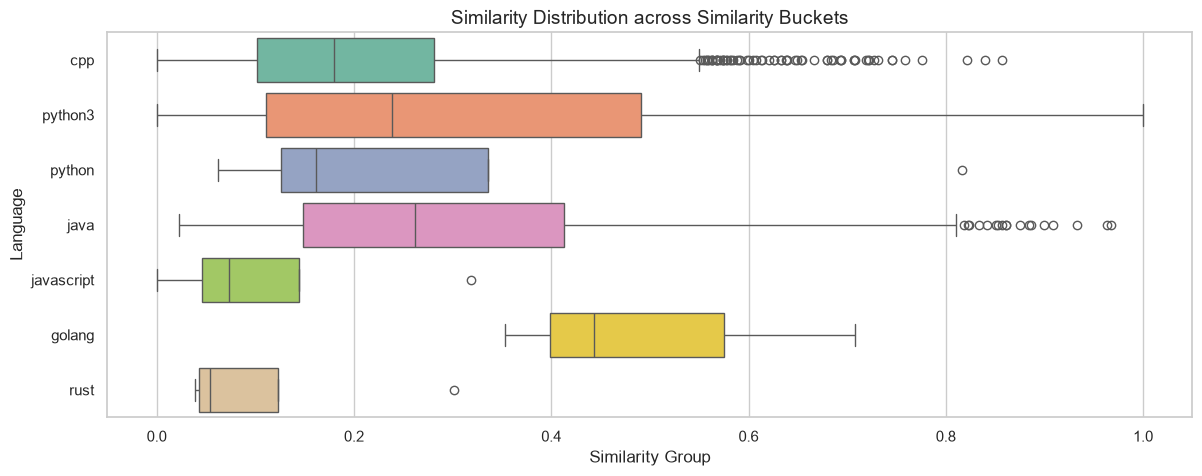

In [71]:
plt.figure(figsize=(14, 5))
sns.boxplot(data=df_diff_questions, x='similarity', y='language', palette='Set2')

plt.title('Similarity Distribution across Similarity Buckets', fontsize=14)
plt.xlabel('Similarity Group')
plt.ylabel('Language')
plt.show()
